In [16]:
import pandas as pd
import numpy as np
import warnings
from scipy import optimize, sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import MinMaxScaler
import gc

In [17]:
# 1. Load files & Feature Engineering
train_path = "./train.csv"
test_path = "./test.csv"
sample_path = "./sample.csv"

full_train = pd.read_csv(train_path)
test_template = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_path)

# standard split: labeled for training, NaN for prediction
train_df = full_train[full_train["Score"].notna()].copy()
predict_df = full_train[full_train["Score"].isna()].copy()
predict_df = test_template[["Id"]].merge(predict_df, on="Id", how="left")

train_df["Score"] = train_df["Score"].astype(int)
y = train_df["Score"].values

# Adding Target Encoding for UserId and ProductId
print("Calculating Target Encoding...")
global_mean = train_df["Score"].mean()
for col in ['UserId', 'ProductId']:
    agg = train_df.groupby(col)['Score'].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    # Use smoothing (lambda=10) so users with 1 review don't skew the data too much
    smooth = (counts * means + 10 * global_mean) / (counts + 10)
    train_df[f'{col}_avg'] = train_df[col].map(smooth).fillna(global_mean)
    predict_df[f'{col}_avg'] = predict_df[col].map(smooth).fillna(global_mean)

def combine_text(df):
    return (df["Summary"].fillna("") + " " + df["Text"].fillna("")).str.lower()

X_train_raw = combine_text(train_df)
X_pred_raw = combine_text(predict_df)

Calculating Target Encoding...


In [18]:
# 2. Text features + Meta features
print("Vectorizing features...")

# Kept the same TF-IDF setup since 150k features seems to be the sweet spot
word_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=100000, min_df=5, stop_words="english", sublinear_tf=True)
char_vec = TfidfVectorizer(ngram_range=(3, 6), max_features=50000, min_df=10, analyzer="char", sublinear_tf=True)

X_train_word = word_vec.fit_transform(X_train_raw)
X_pred_word = word_vec.transform(X_pred_raw)
X_train_char = char_vec.fit_transform(X_train_raw)
X_pred_char = char_vec.transform(X_pred_raw)

# Adding some numerical meta features including the target averages from above.
def get_meta_features(df):
    data = pd.DataFrame()
    data['text_len'] = df['Text'].fillna("").apply(len)
    data['summary_len'] = df['Summary'].fillna("").apply(len)
    data['help_ratio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1)
    data['user_avg'] = df['UserId_avg']
    data['prod_avg'] = df['ProductId_avg']
    return data.values

meta_train = get_meta_features(train_df)
meta_pred = get_meta_features(predict_df)

# Need to scale these for the models. 
# Using MinMaxScaler instead of StandardScaler because ComplementNB hates negative numbers.
scaler = MinMaxScaler()
meta_train_scaled = scaler.fit_transform(meta_train)
meta_pred_scaled = scaler.transform(meta_pred)

# Combine word + char + numerical meta features
X_train = sparse.hstack([X_train_word, X_train_char, sparse.csr_matrix(meta_train_scaled)]).tocsr()
X_pred = sparse.hstack([X_pred_word, X_pred_char, sparse.csr_matrix(meta_pred_scaled)]).tocsr()

print("Total features:", X_train.shape[1])
gc.collect()

Vectorizing features...
Total features: 150005


3223

In [21]:
# 3. Cross-validation and model blending
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = np.zeros((len(train_df), 5))
test_probs = np.zeros((len(predict_df), 5))

print("Starting 5-fold training...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    m1 = SGDClassifier(loss="log_loss", alpha=2e-5, max_iter=3000, tol=1e-4, random_state=42)
    m1.fit(X_tr, y_tr)

    m2 = LogisticRegression(C=0.8, solver="lbfgs", max_iter=2000)
    m2.fit(X_tr, y_tr)

    m3 = ComplementNB(alpha=0.1)
    m3.fit(X_tr, y_tr)

    # Slightly adjusted blend weights to see if meta features help LogReg more
    va_prob = (
        0.55 * m1.predict_proba(X_va) +
        0.30 * m2.predict_proba(X_va) +
        0.15 * m3.predict_proba(X_va)
    )
    oof_probs[va_idx] = va_prob

    test_prob = (
        0.55 * m1.predict_proba(X_pred) +
        0.30 * m2.predict_proba(X_pred) +
        0.15 * m3.predict_proba(X_pred)
    )
    test_probs += test_prob / skf.n_splits
    print(f"fold {fold} complete")

Starting 5-fold training...
fold 1 complete
fold 2 complete
fold 3 complete
fold 4 complete
fold 5 complete


In [22]:
# 4. QWK optimization
oof_cont = np.dot(oof_probs, np.array([1, 2, 3, 4, 5]))
test_cont = np.dot(test_probs, np.array([1, 2, 3, 4, 5]))

class OptimizedRounder:
    def __init__(self):
        self.coeff = [1.5, 2.5, 3.5, 4.5]
    def _kappa_loss(self, coeff, X, y):
        X_p = pd.cut(X, [-np.inf] + list(np.sort(coeff)) + [np.inf], labels=[1, 2, 3, 4, 5])
        return -cohen_kappa_score(y, X_p, weights="quadratic")
    def fit(self, X, y):
        res = optimize.minimize(self._kappa_loss, self.coeff, args=(X, y), method="Nelder-Mead")
        self.coeff = res.x
    def predict(self, X):
        return pd.cut(X, [-np.inf] + list(np.sort(self.coeff)) + [np.inf], labels=[1, 2, 3, 4, 5])

print("Running QWK optimization...")
optR = OptimizedRounder()
optR.fit(oof_cont, y)
final_predictions = optR.predict(test_cont)

Running QWK optimization...



Saved submission.csv
Prediction distribution:
Score
1     524
2     751
3    1643
4    3604
5    7454
Name: count, dtype: int64

Process finished! Saving distribution plot...


Matplotlib is building the font cache; this may take a moment.


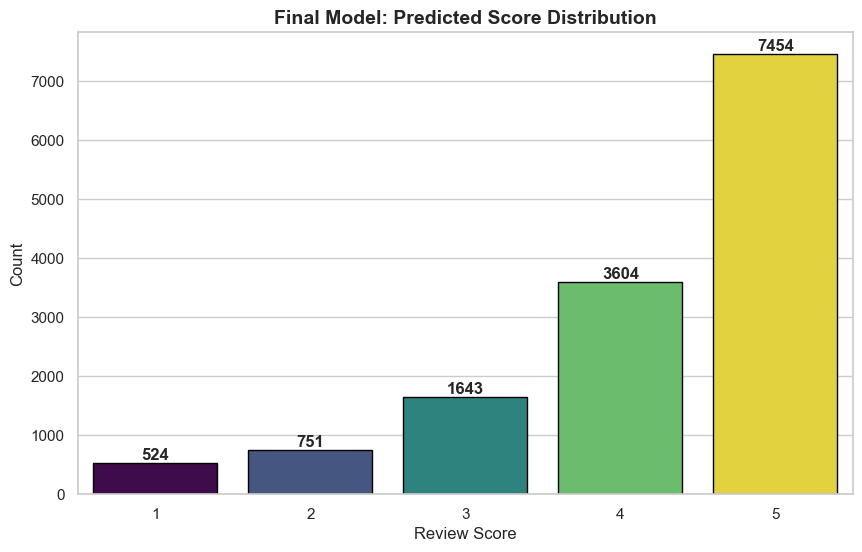

In [24]:
# 5. Build submission
submission = sample_sub.copy()
submission["Score"] = final_predictions.astype(int)
submission.to_csv("submission.csv", index=False)

print("\nSaved submission.csv")
print("Prediction distribution:")
print(submission["Score"].value_counts().sort_index())

print("\nProcess finished! Saving distribution plot...")
scores_list = [1, 2, 3, 4, 5]
counts_list = submission["Score"].value_counts().sort_index().tolist()

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x=scores_list, y=counts_list, hue=scores_list, palette='viridis', legend=False, edgecolor='black')
plt.title('Final Model: Predicted Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(counts_list):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()